# CCO10: Re-Pass CCO08

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import scipy
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import ListedColormap
import anndata as ad

In [2]:
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO08"
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO10"

In [3]:
os.system(f"mkdir -p {WORK_DIR}")

0

In [4]:
os.system(f"mkdir -p {WORK_DIR}/adata")
os.system(f"mkdir -p {WORK_DIR}/dotplot")
os.system(f"mkdir -p {WORK_DIR}/UMAP")
os.system(f"mkdir -p {WORK_DIR}/distribution")

0

In [4]:
samples = ['ALL', 'VO', 'HO', 'ReAgg_CM', 'Fus_HO', 'VasHO']
samples_old = ['ALL','VO','HO','CA','VHO','VCO']
cell_types = ['CM','EC','EP','PV','UN']

colormap_cell_types = {
    "CM": (60/255, 170/255, 60/255),
    "EC": (230/255, 80/255, 160/255),
    "EP": (141/255, 160/255, 203/255),
    "PV": (255/255, 210/255, 60/255),
    "UN": (190/255, 190/255, 190/255),
}

colormap_subclusters = {
    "CM_1": (30/255, 120/255, 30/255),
    "CM_2": (150/255, 230/255, 150/255),
    "CM_3": (15/255, 80/255, 15/255),
    "CM_4": (90/255, 190/255, 90/255),
    
    "EC_1": (255/255, 200/255, 230/255),
    "EC_2": (230/255, 80/255, 160/255),
    "EC_3": (180/255, 30/255, 120/255),
    
    "PV_1": (255/255, 250/255, 200/255),
    "PV_2": (255/255, 245/255, 175/255),
    "PV_3": (255/255, 240/255, 150/255),
    "PV_4": (255/255, 235/255, 125/255),
    "PV_5": (255/255, 230/255, 100/255),
    "PV_6": (255/255, 220/255, 75/255),
    "PV_7": (255/255, 210/255, 50/255),
    "PV_8": (255/255, 200/255, 25/255),
    "PV_9": (240/255, 180/255, 10/255),
    "PV_10": (220/255, 160/255, 0/255),

    "EP": (141/255, 160/255, 203/255),

    "UN": (190/255, 190/255, 190/255),
}

colormap_cpdb = {
    "CM": (60/255, 170/255, 60/255),
    "EC": (230/255, 80/255, 160/255),
    "EP": (141/255, 160/255, 203/255),
    "PV": (255/255, 235/255, 125/255),
    "FB": (240/255, 180/255, 20/255),
    "SM": (220/255, 160/255, 30/255),
    "UN": (190/255, 190/255, 190/255),
    "OTH": (170/255, 170/255, 170/255),
}

# 0. Prepare data

In [29]:
samples_map = {
    'ALL': 'ALL', 
    'VO': 'VO', 
    'HO': 'HO', 
    'CA': 'ReAgg_CM', 
    'VHO': 'Fus_HO', 
    'VCO': 'VasHO'
}

In [40]:
os.system(f"ln -s {PREV_DIR}/adata/cell_type_labelled {WORK_DIR}/adata/")

0

In [30]:
os.system(f"rm -r {WORK_DIR}/adata/cell_type_subclustered")
os.system(f"mkdir -p {WORK_DIR}/adata/cell_type_subclustered")

for f in glob.glob(f"{PREV_DIR}/adata/cell_type_subclustered/*.h5ad"):
    celltype = f.split("/")[-1].strip(".h5ad")
    adata = sc.read_h5ad(f)
    
    if celltype == "MU":
        adata.obs["cell_type_subcluster"] = adata.obs["cell_type_subcluster"].map({
            'FB': 'PV_9', 
            'PR_1': 'PV_1', 
            'PR_2': 'PV_2', 
            'PR_3': 'PV_3', 
            'PR_4': 'PV_4', 
            'PR_5': 'PV_5', 
            'PR_6': 'PV_6', 
            'PR_7': 'PV_7', 
            'PR_8': 'PV_8', 
            'SM': 'PV_10'
        })
        adata.obs["cell_type_subcluster"] = adata.obs["cell_type_subcluster"].astype("category")
        adata.obs["cell_type"] = adata.obs["cell_type"].map({"MU": "PV"})
        adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
        celltype = "PV"
        
    adata.obs['batch'] = adata.obs['batch'].map(samples_map)
    adata.obs['batch'] = adata.obs['batch'].astype("category")
    
    adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{celltype}.h5ad")

In [31]:
os.system(f"rm -r {WORK_DIR}/adata/sample_recollect")
os.system(f"mkdir -p {WORK_DIR}/adata/sample_recollect")

for i, f in enumerate(glob.glob(f"{WORK_DIR}/adata/cell_type_subclustered/*.h5ad")):
    if i == 0:
        adata_full = sc.read_h5ad(f)
    else:
        adata_full = sc.concat([adata_full, sc.read_h5ad(f)])
adata_full.write(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

for batch in adata_full.obs["batch"].unique():
    adata_full[adata_full.obs["batch"] == batch].write(f"{WORK_DIR}/adata/sample_recollect/{batch}.h5ad")

# 1. Inspect the Leiden clustered data

In [5]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")

In [6]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

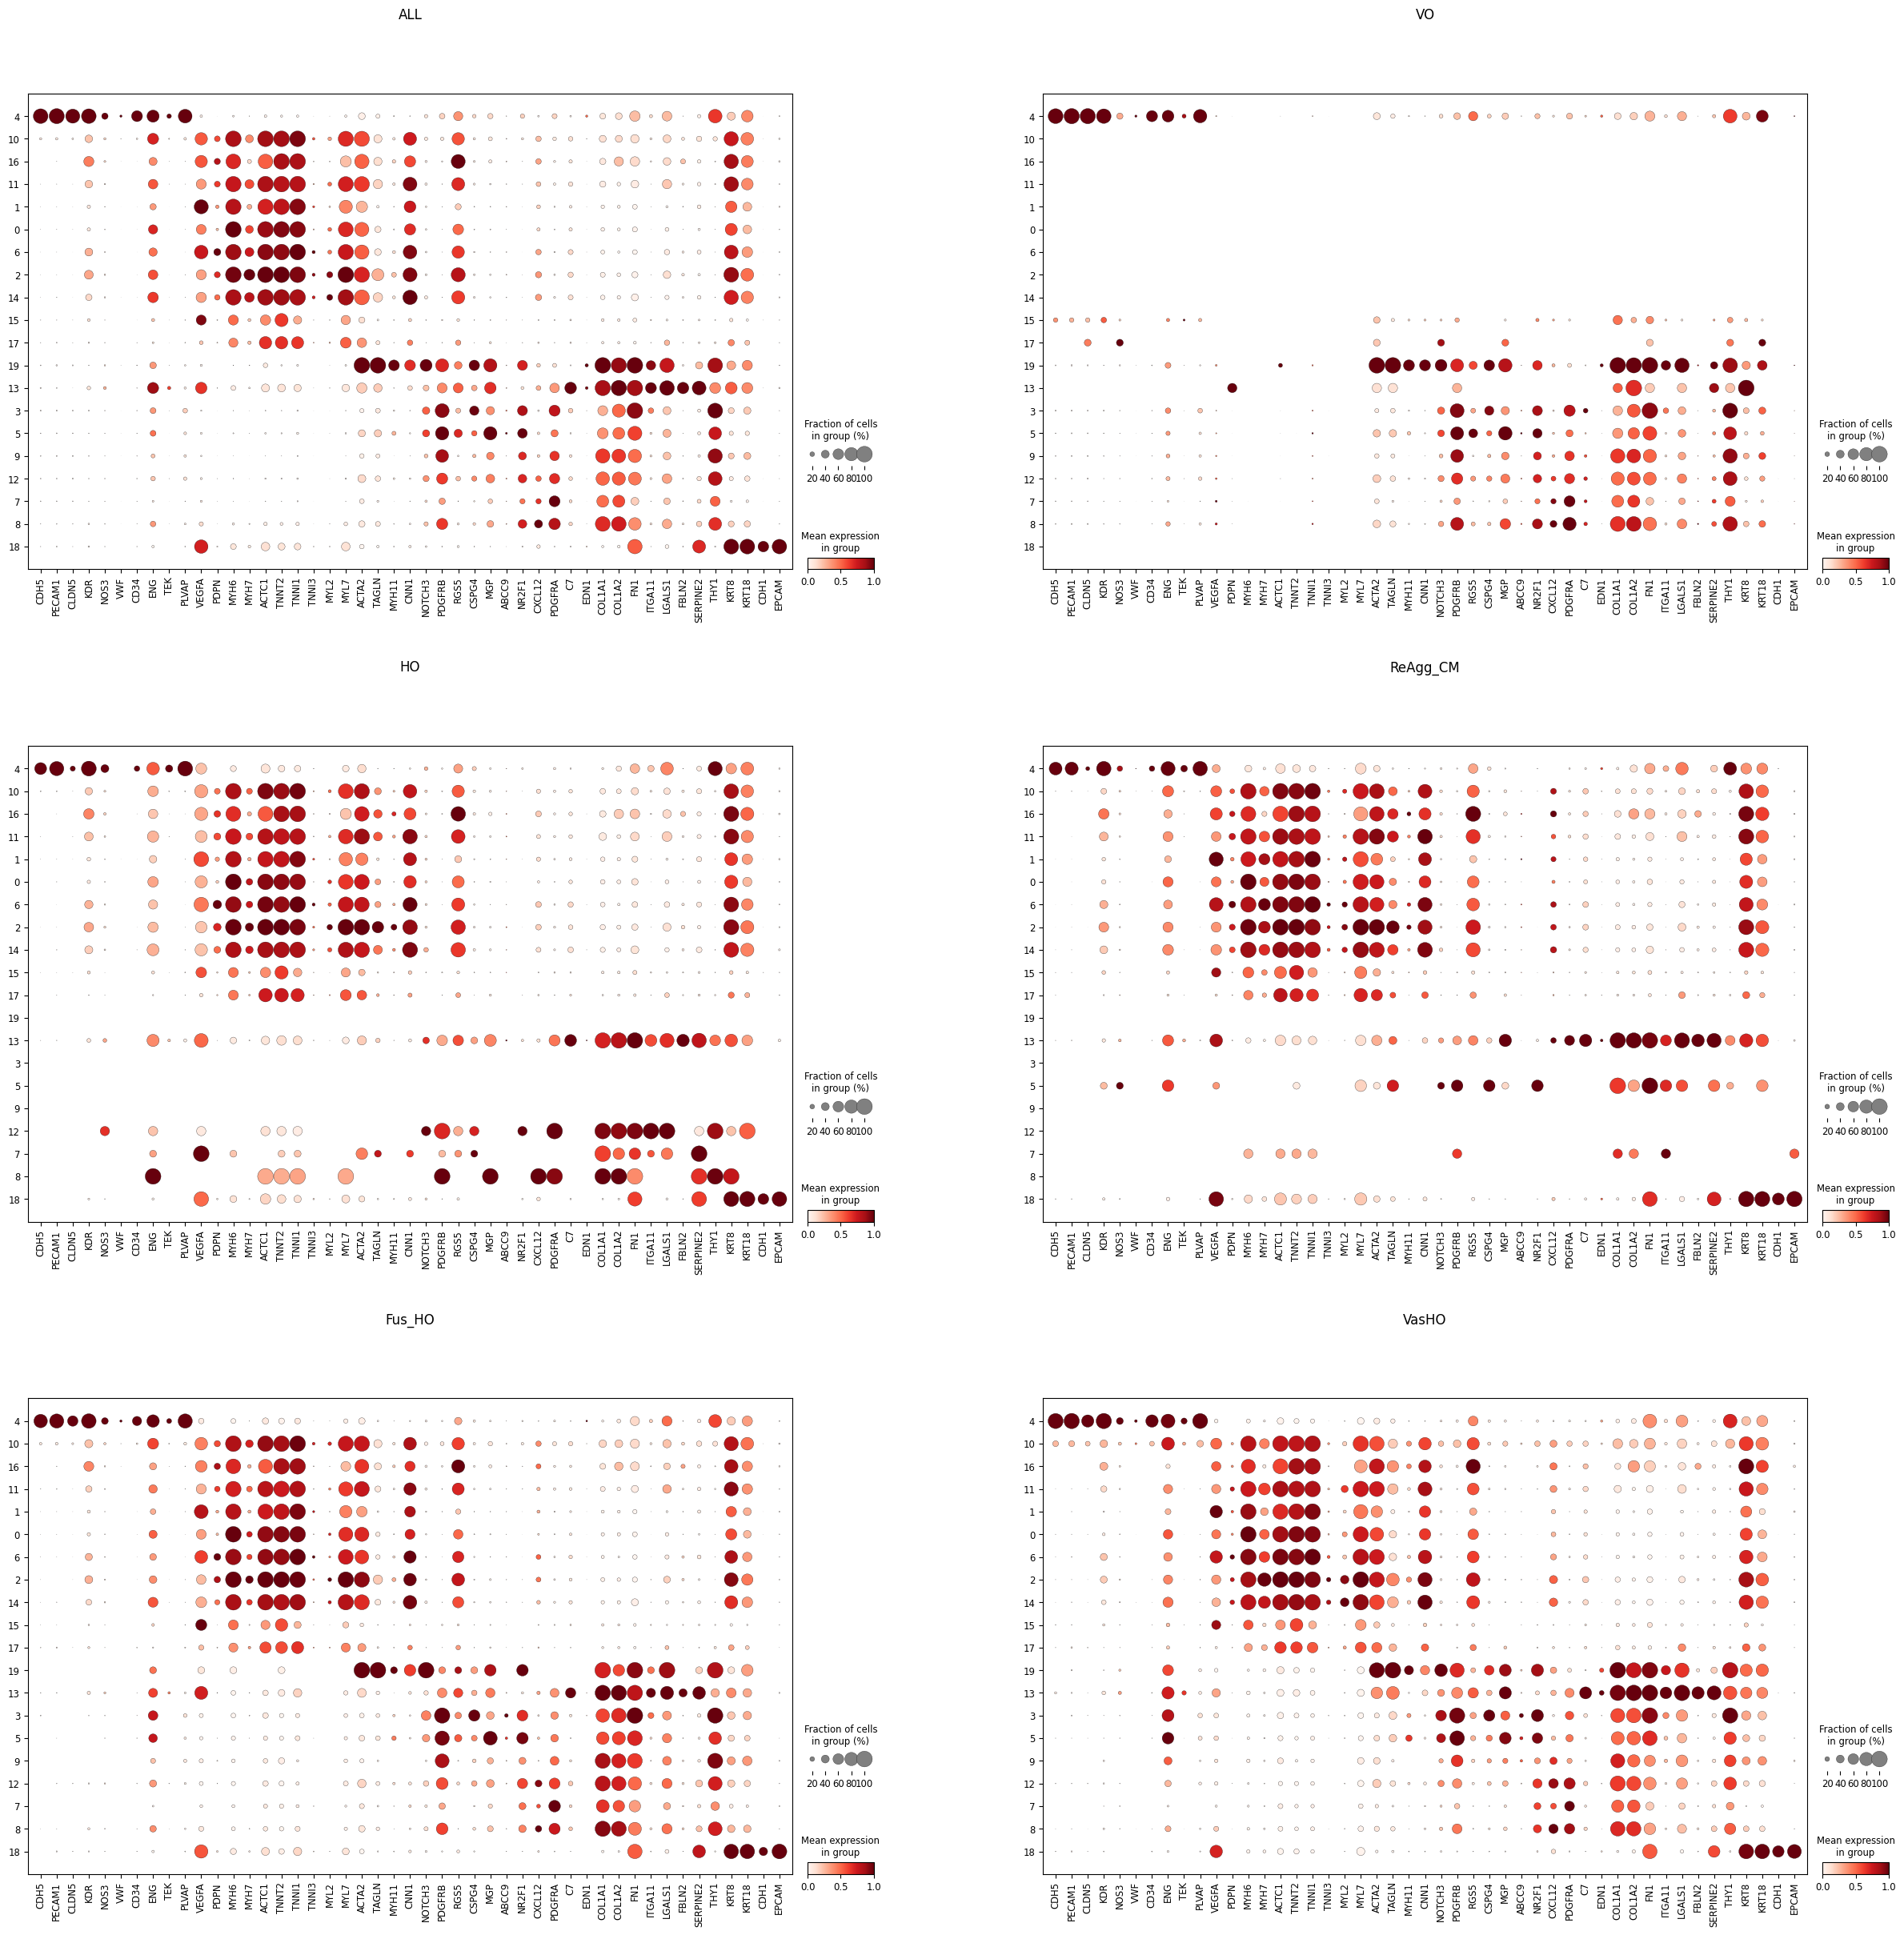

In [8]:
import warnings
warnings.filterwarnings("ignore")

fig, axs = plt.subplots(3, 2, figsize=(30,30), layout="constrained")
axs = axs.flatten()

marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

cluster_order = [4, 10, 16, 11, 1, 0, 6, 2, 14, 15, 17, 19, 13, 3, 5, 9, 12, 7, 8, 18]

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples_old[i]]
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).any():
            continue
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    sc.pl.dotplot(adata, 
                  marker_dict, 
                  categories_order=cluster_order,
                  groupby="leiden", 
                  standard_scale="var", 
                  ax=axs[i], 
                  title=sample, 
                  show=False)
    
plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.png')
plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.svg')
plt.show()

In [9]:
celltypes_dict = {
    '0': 'CM', 
    '1': 'CM',
    '2': 'CM',
    '3': 'MU',
    '4': 'EC',
    '5': 'MU',
    '6': 'CM',
    '7': 'MU',
    '8': 'MU',
    '9': 'MU',
    '10': 'CM',
    '11': 'CM',
    '12': 'MU',
    '13': 'MU',
    '14': 'CM',
    '15': 'UN',
    '16': 'CM',
    '17': 'UN',
    '18': 'EP',
    '19': 'MU',
}

CM_order = [10, 16, 11, 1, 0, 6, 2, 14]
CM_color_min = (150/255, 230/255, 150/255)
CM_color_max = (15/255, 80/255, 15/255)

# MU_order = [13, 19, 3, 5, 9, 12, 7, 8]
MU_order = [19, 13, 8, 7, 12, 9, 5, 3]
MU_color_min = (240/255, 180/255, 20/255)
MU_color_max = (255/255, 250/255, 200/255)

def getColor(ld):
    ct = celltypes_dict[str(ld)]
    if ct in ("EP", "EC"):
        return colormap_cell_types[ct]
    elif ct == "CM":
        idx = CM_order.index(ld)
        clr = []
        for i in range(0, 3):
            clr.append(CM_color_min[i] + (CM_color_max[i]-CM_color_min[i]) / (len(CM_order)-1) * idx)
        return tuple(clr)
    elif ct == "MU":
        idx = MU_order.index(ld)
        clr = []
        for i in range(0, 3):
            clr.append(MU_color_min[i] + (MU_color_max[i]-MU_color_min[i]) / (len(MU_order)-1) * idx)
        return tuple(clr)
    else:
        clr = list(colormap_cell_types[ct])
        for i in range(0, len(clr)):
            np.random.seed(ld)
            clr[i] += (np.random.random() - 0.5) / 4
            if clr[i] > 1:
                clr[i] = 1
            elif clr[i] < 0:
                clr[i] = 0
        return tuple(clr)

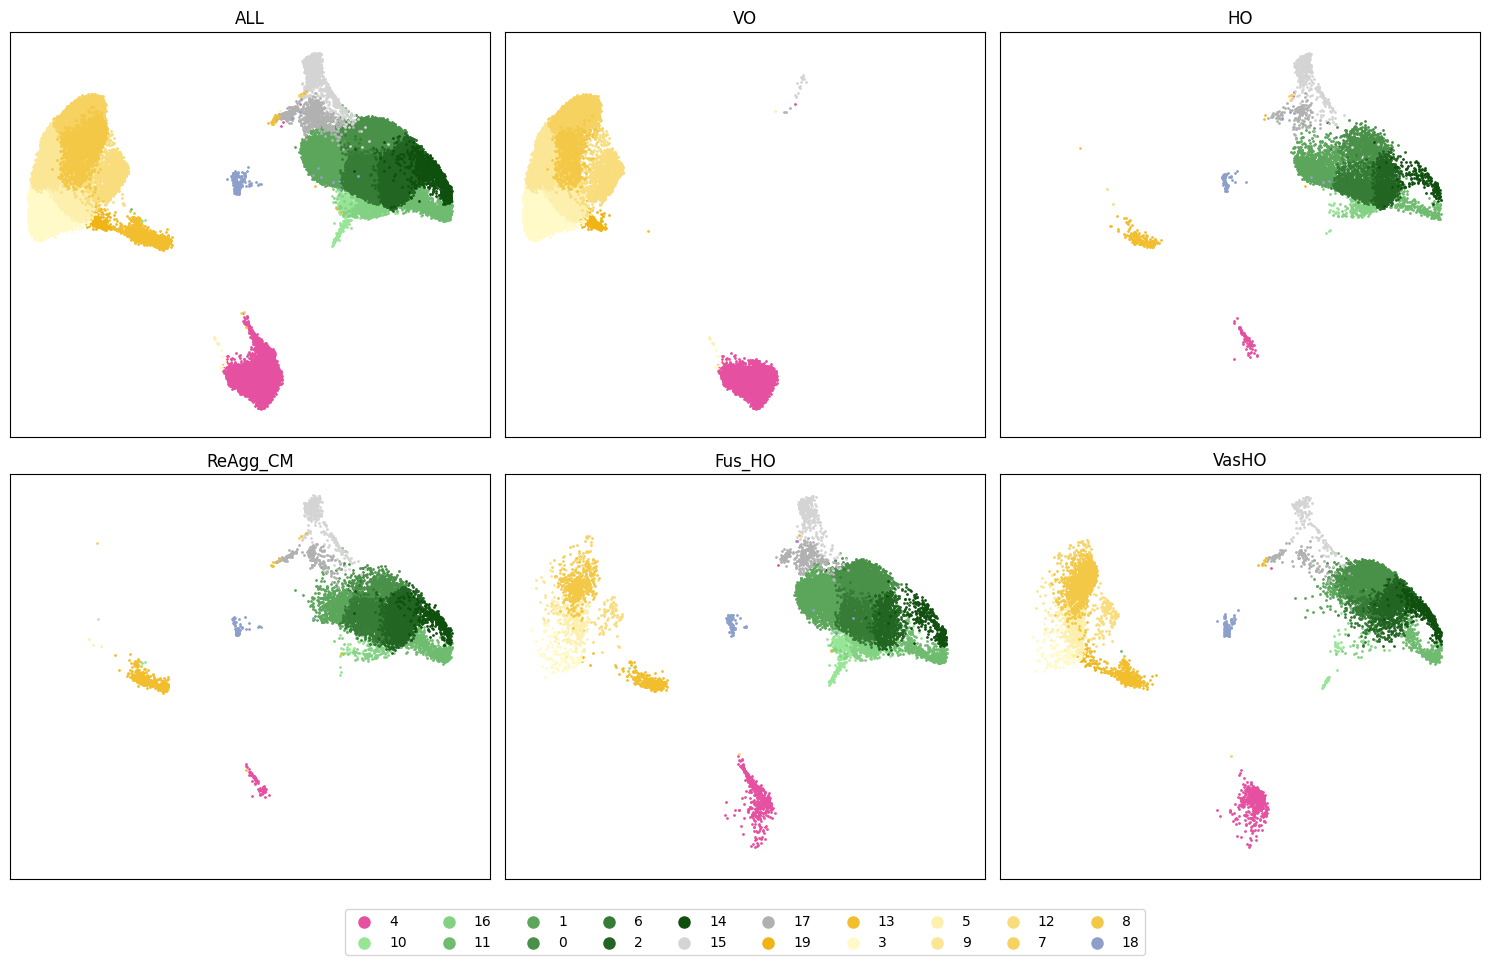

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples_old[i]]
    
    # for j, ld in enumerate(adata_all.obs["leiden"].unique().sort_values()):
    for j, ld in enumerate(cluster_order):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 0], 
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 1], 
            label=ld, 
            color=getColor(ld), 
            s=1)
        if i == 0:
            handles.append(sbplt)
            labels.append(ld)
        
    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.075)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.svg', bbox_inches="tight")
plt.show()

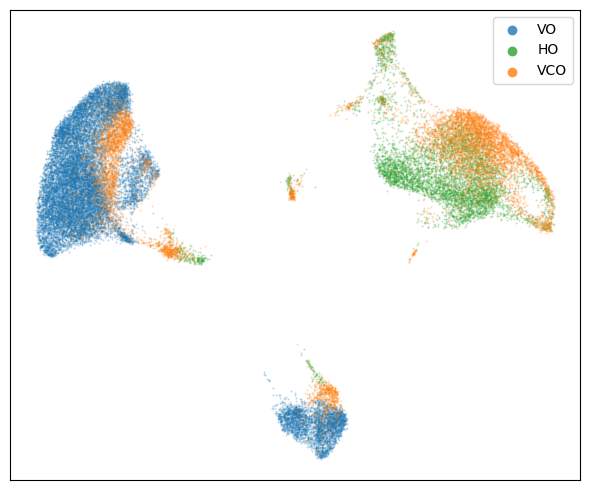

In [12]:
bc1 = "VO"
bc2 = "HO"
bc3 = "VCO"

adata_vo = adata_all[adata_all.obs['batch'] == bc1]
adata_ho = adata_all[adata_all.obs['batch'] == bc2]
adata_vco = adata_all[adata_all.obs['batch'] == bc3]

fig, ax = plt.subplots(1, 1, figsize=(6,5))
colors = plt.get_cmap('tab10').colors

ax.scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label=bc1, s=2, alpha=0.3, linewidths=0)
ax.scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label=bc2, s=2, alpha=0.3, linewidths=0)
ax.scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label=bc3, s=2, alpha=0.3, linewidths=0)
# ax.set_title(f"{bc1} + {bc2}")
leg = ax.legend(markerscale=5)
ax.set_xticks([])
ax.set_yticks([])

for lh in leg.legend_handles:
    lh.set_alpha(0.8)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.svg', bbox_inches="tight")
plt.show()

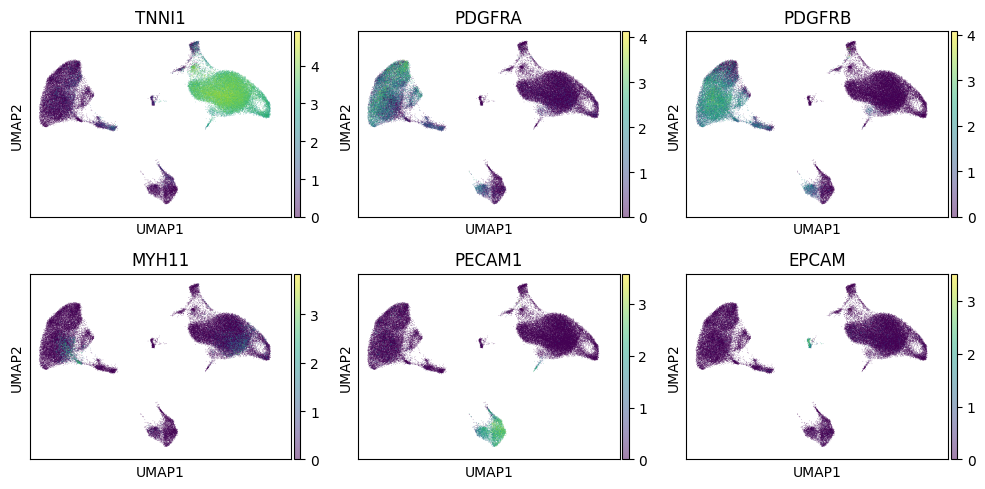

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
axs = axs.flatten()

for i, gene in enumerate(('TNNI1','PDGFRA','PDGFRB','MYH11','PECAM1','EPCAM')):
    sc.pl.umap(adata_all, color=gene, show=False, ax=axs[i], title=gene, s=1, alpha=0.5)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/marker_color.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/marker_color.complete.svg', bbox_inches="tight")
plt.show()

# 2. Celltype split and recluster

## 2.1 CM

In [14]:
ct = "CM"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

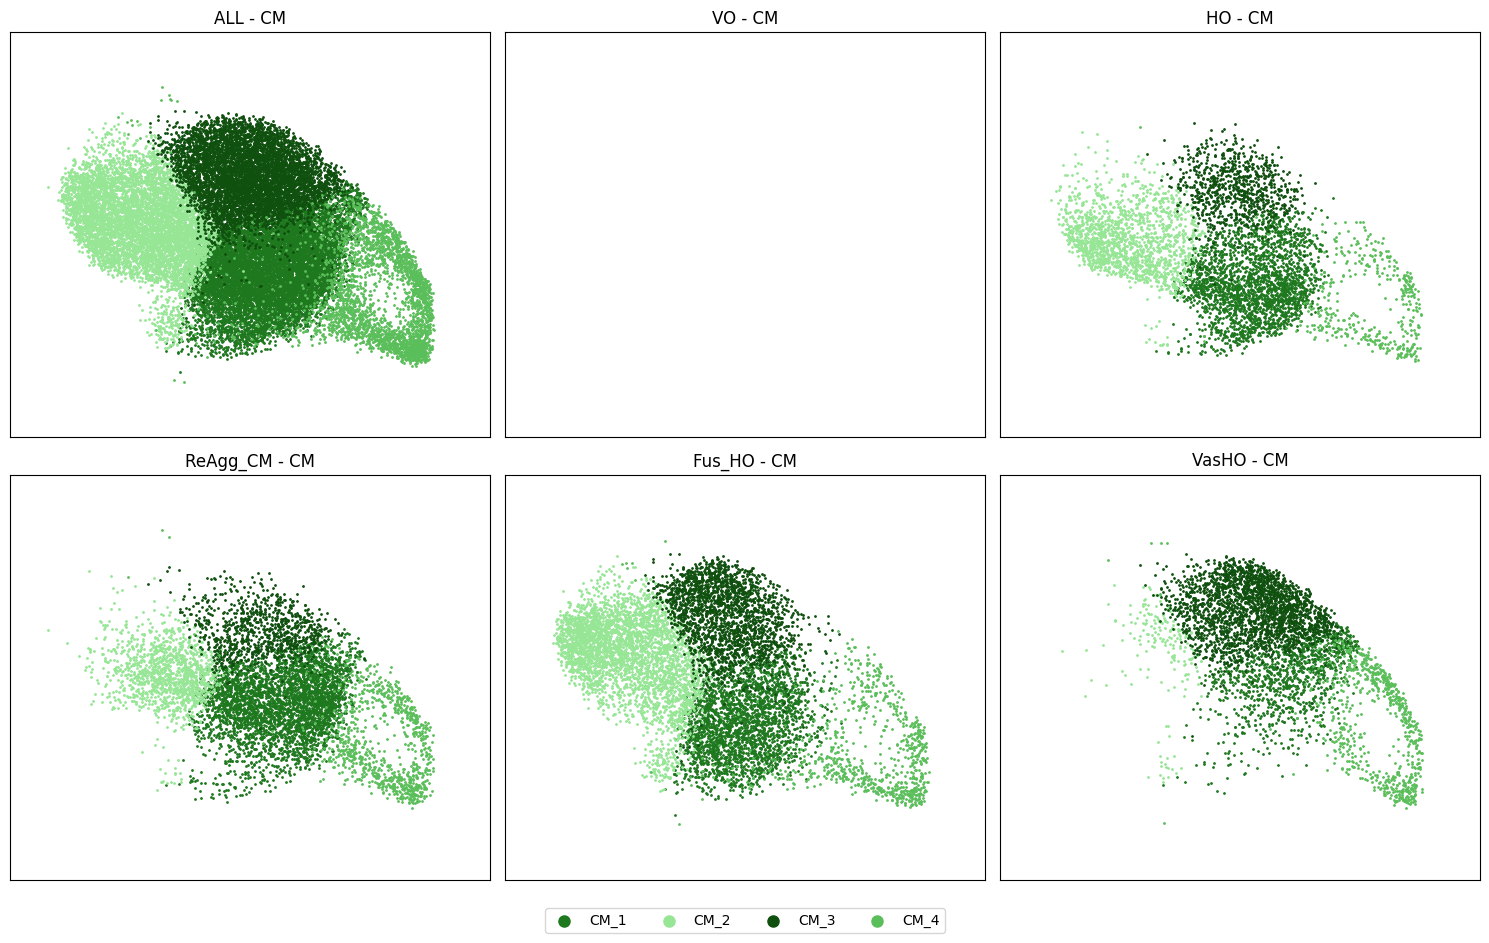

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([7, 20])
    ax.set_ylim([5, 15])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

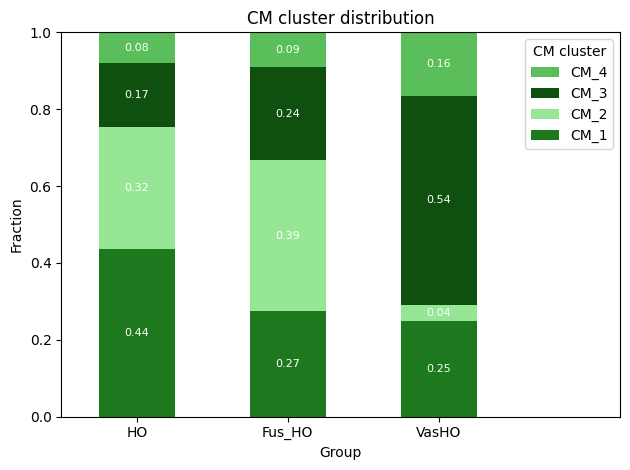

In [19]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'ReAgg_CM' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 3.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

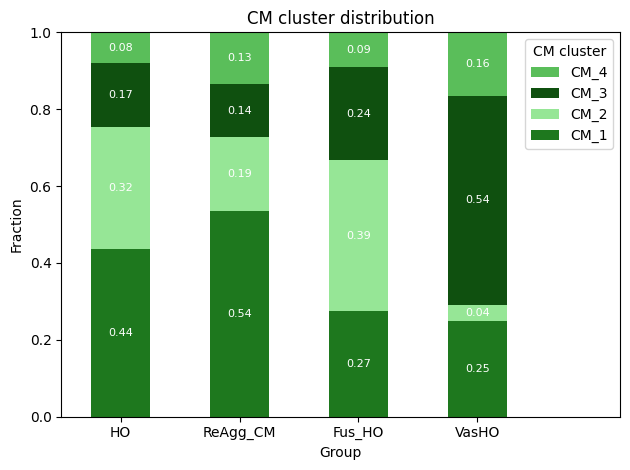

In [20]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

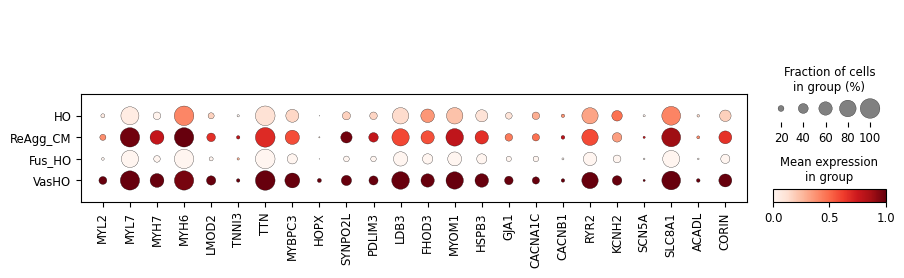

In [22]:
marker_dict = ['MYL2', 'MYL7', 'MYH7', 'MYH6', 'LMOD2', 'TNNI3', 'TTN', 'MYBPC3', 
               'HOPX', 'SYNPO2L', 'PDLIM3', 'LDB3', 'FHOD3', 'MYOM1','HSPB3', 
               'GJA1', 'CACNA1C', 'CACNB1', 'RYR2', 'KCNH2', 'SCN5A', 'SLC8A1', 
               'ACADL', 'CORIN']
categories_order = ['HO', 'ReAgg_CM', 'Fus_HO', 'VasHO']

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.2 EC

In [23]:
ct = "EC"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

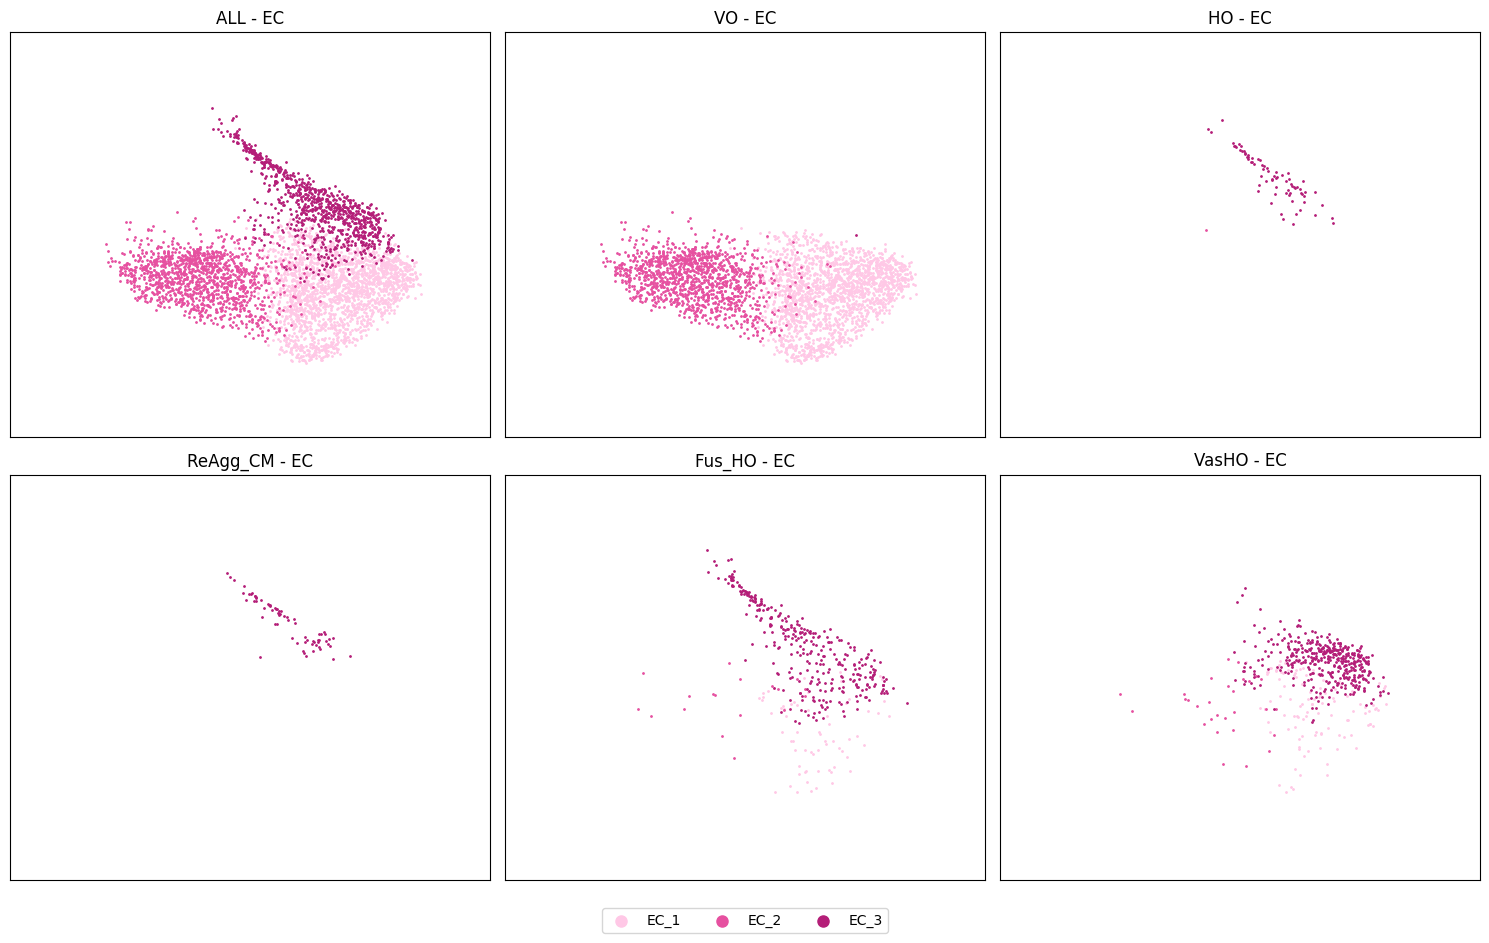

In [24]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([2, 8])
    ax.set_ylim([-6, 3])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

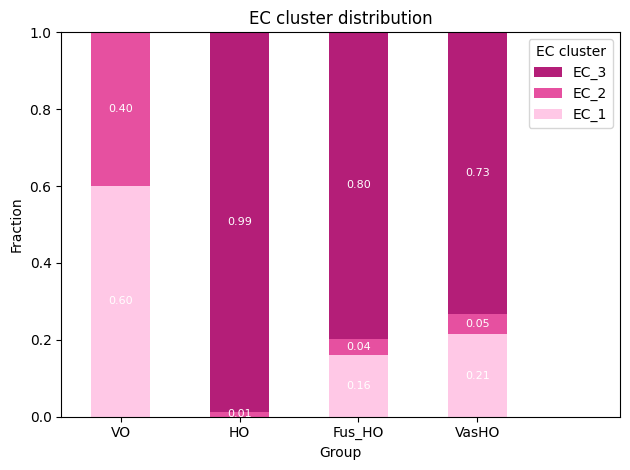

In [25]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'ReAgg_CM':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

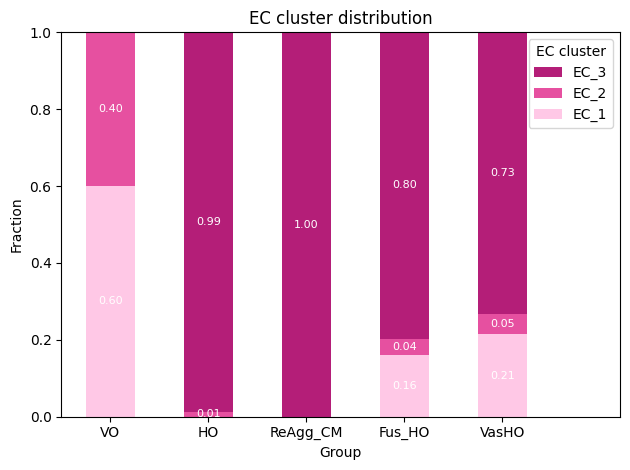

In [26]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

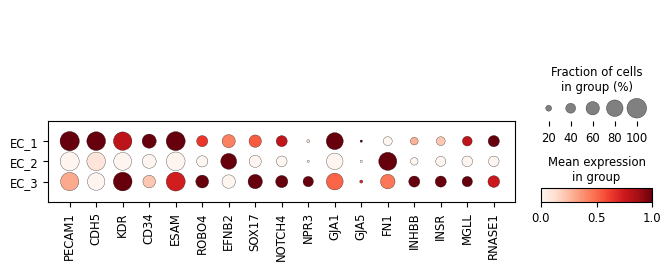

In [27]:
marker_dict = ['PECAM1', 'CDH5', 'KDR', 'CD34', 'ESAM','ROBO4','EFNB2', 'SOX17', 'NOTCH4', 
               'NPR3', 'GJA1','GJA5','FN1', 'INHBB', 'INSR', 'MGLL', 'RNASE1']

sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", show=False)
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.3 PV

In [28]:
ct = "PV"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

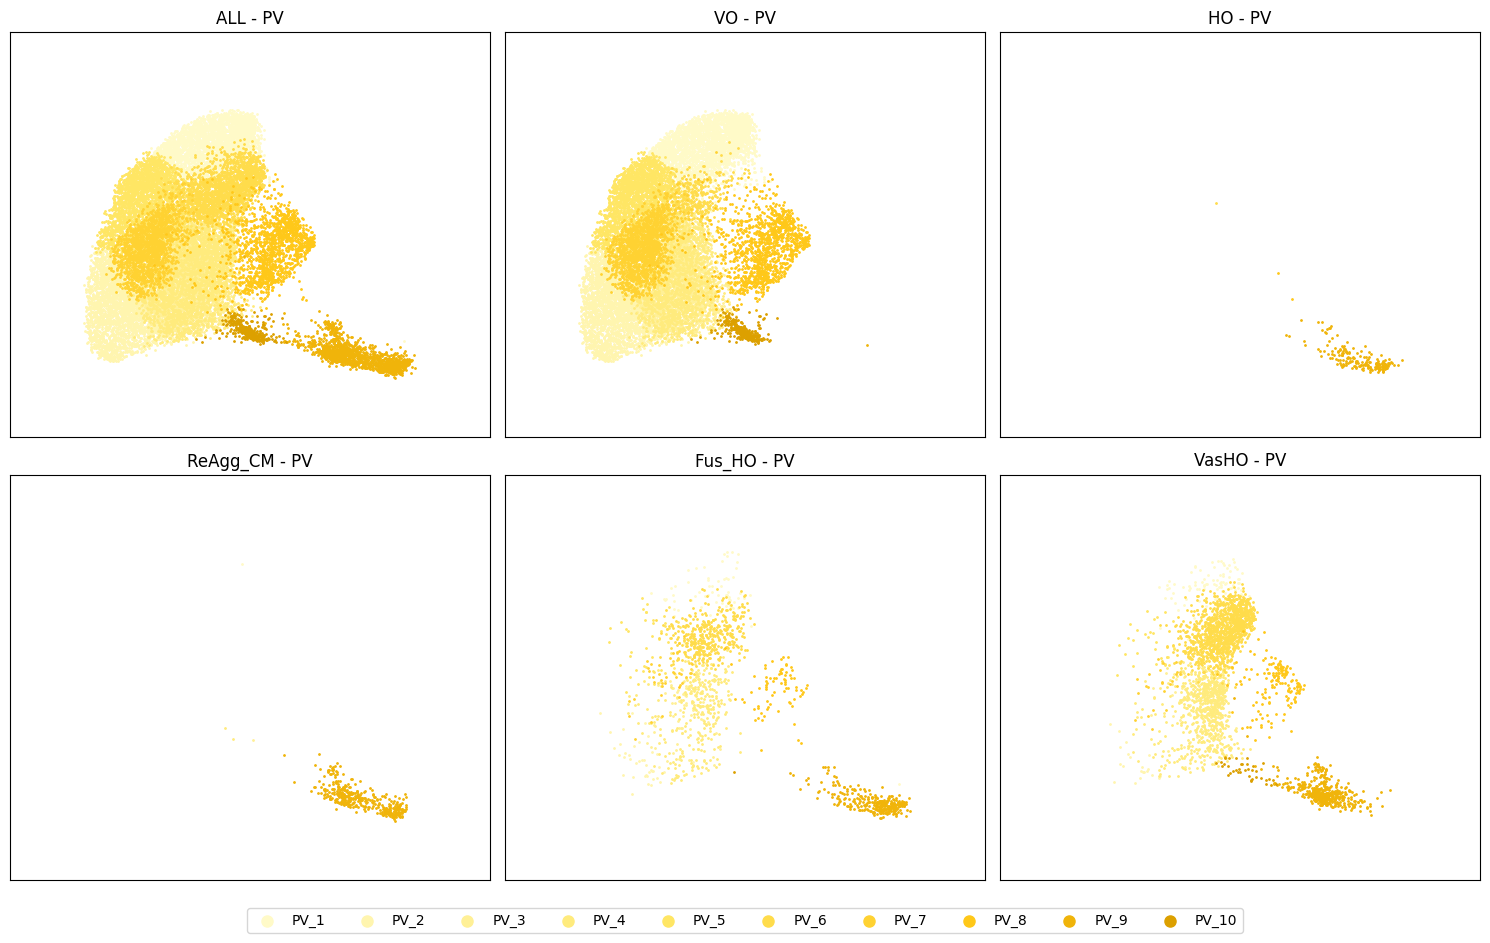

In [33]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in ("PV_1", "PV_2", "PV_3", "PV_4", "PV_5", "PV_6", "PV_7", "PV_8", "PV_9", "PV_10"):
    # for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([-12, 2])
    ax.set_ylim([3, 17])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=12,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

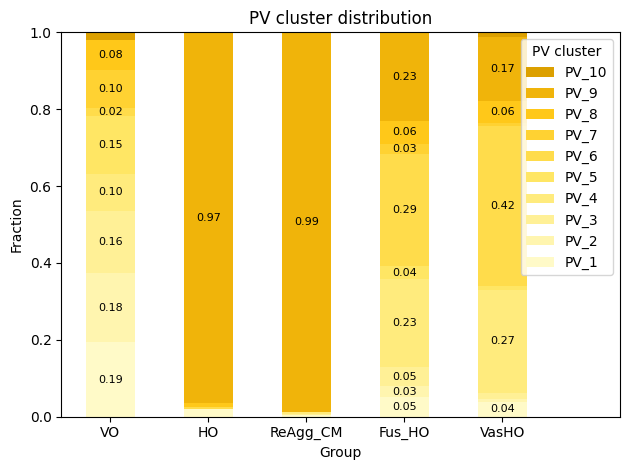

In [36]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T
df = df[["PV_1", "PV_2", "PV_3", "PV_4", "PV_5", "PV_6", "PV_7", "PV_8", "PV_9", "PV_10"]]

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

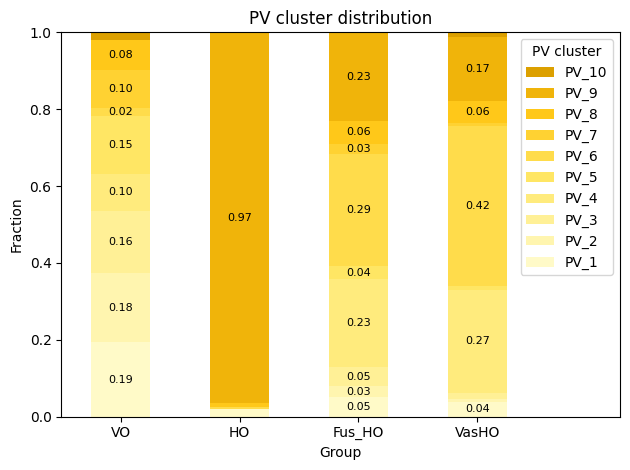

In [37]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == "ReAgg_CM":
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T
df = df[["PV_1", "PV_2", "PV_3", "PV_4", "PV_5", "PV_6", "PV_7", "PV_8", "PV_9", "PV_10"]]

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

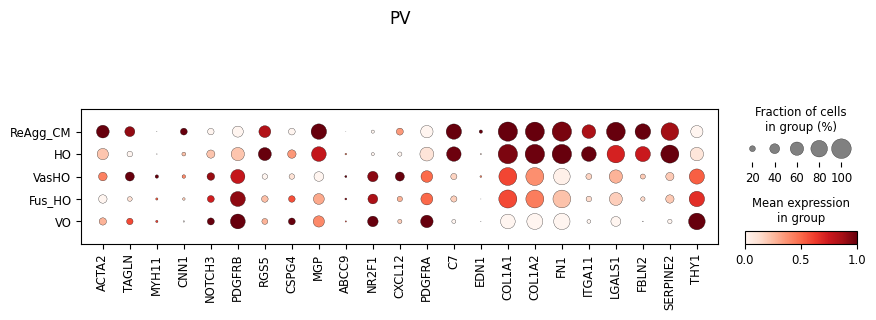

In [39]:
marker_dict = ["ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", 
               "MGP", "ABCC9", "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", 
               "COL1A2", "FN1", "ITGA11", "LGALS1", "FBLN2", "SERPINE2", "THY1"]

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", title=ct, show=False)
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.4 recollect

In [40]:
adata_all = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/ALL.h5ad')

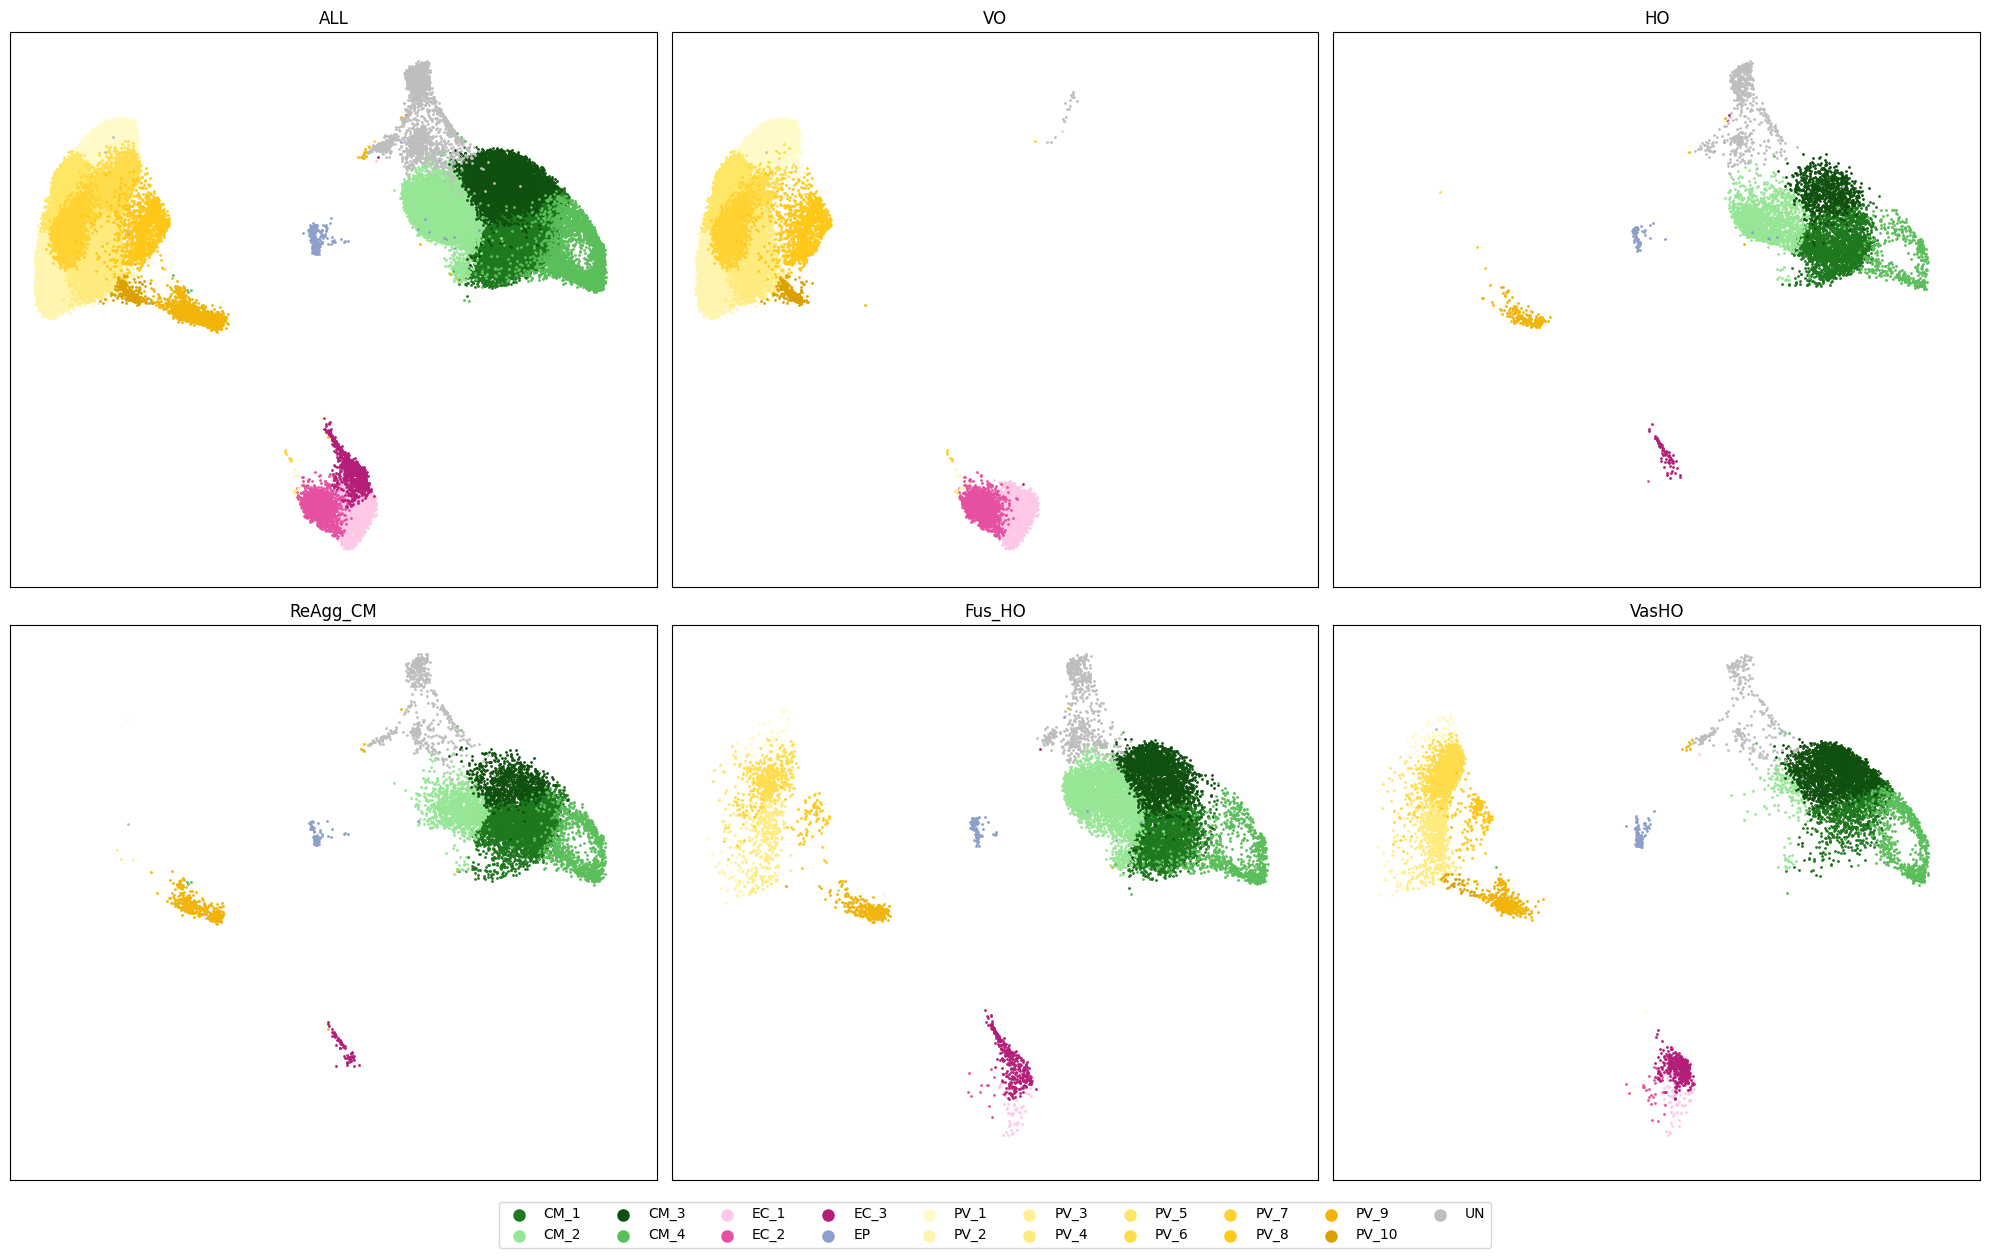

In [41]:
fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):

    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    
    for j, cts in enumerate(adata_all.obs["cell_type_subcluster"].unique().sort_values()):
        sc_plot = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 1], 
            label=cts, 
            color=colormap_subclusters[cts], 
            s=1)
                
        if i == 0:
            handles.append(sc_plot)
            labels.append(cts)

    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_label.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_label.complete.svg', bbox_inches="tight")
plt.show()

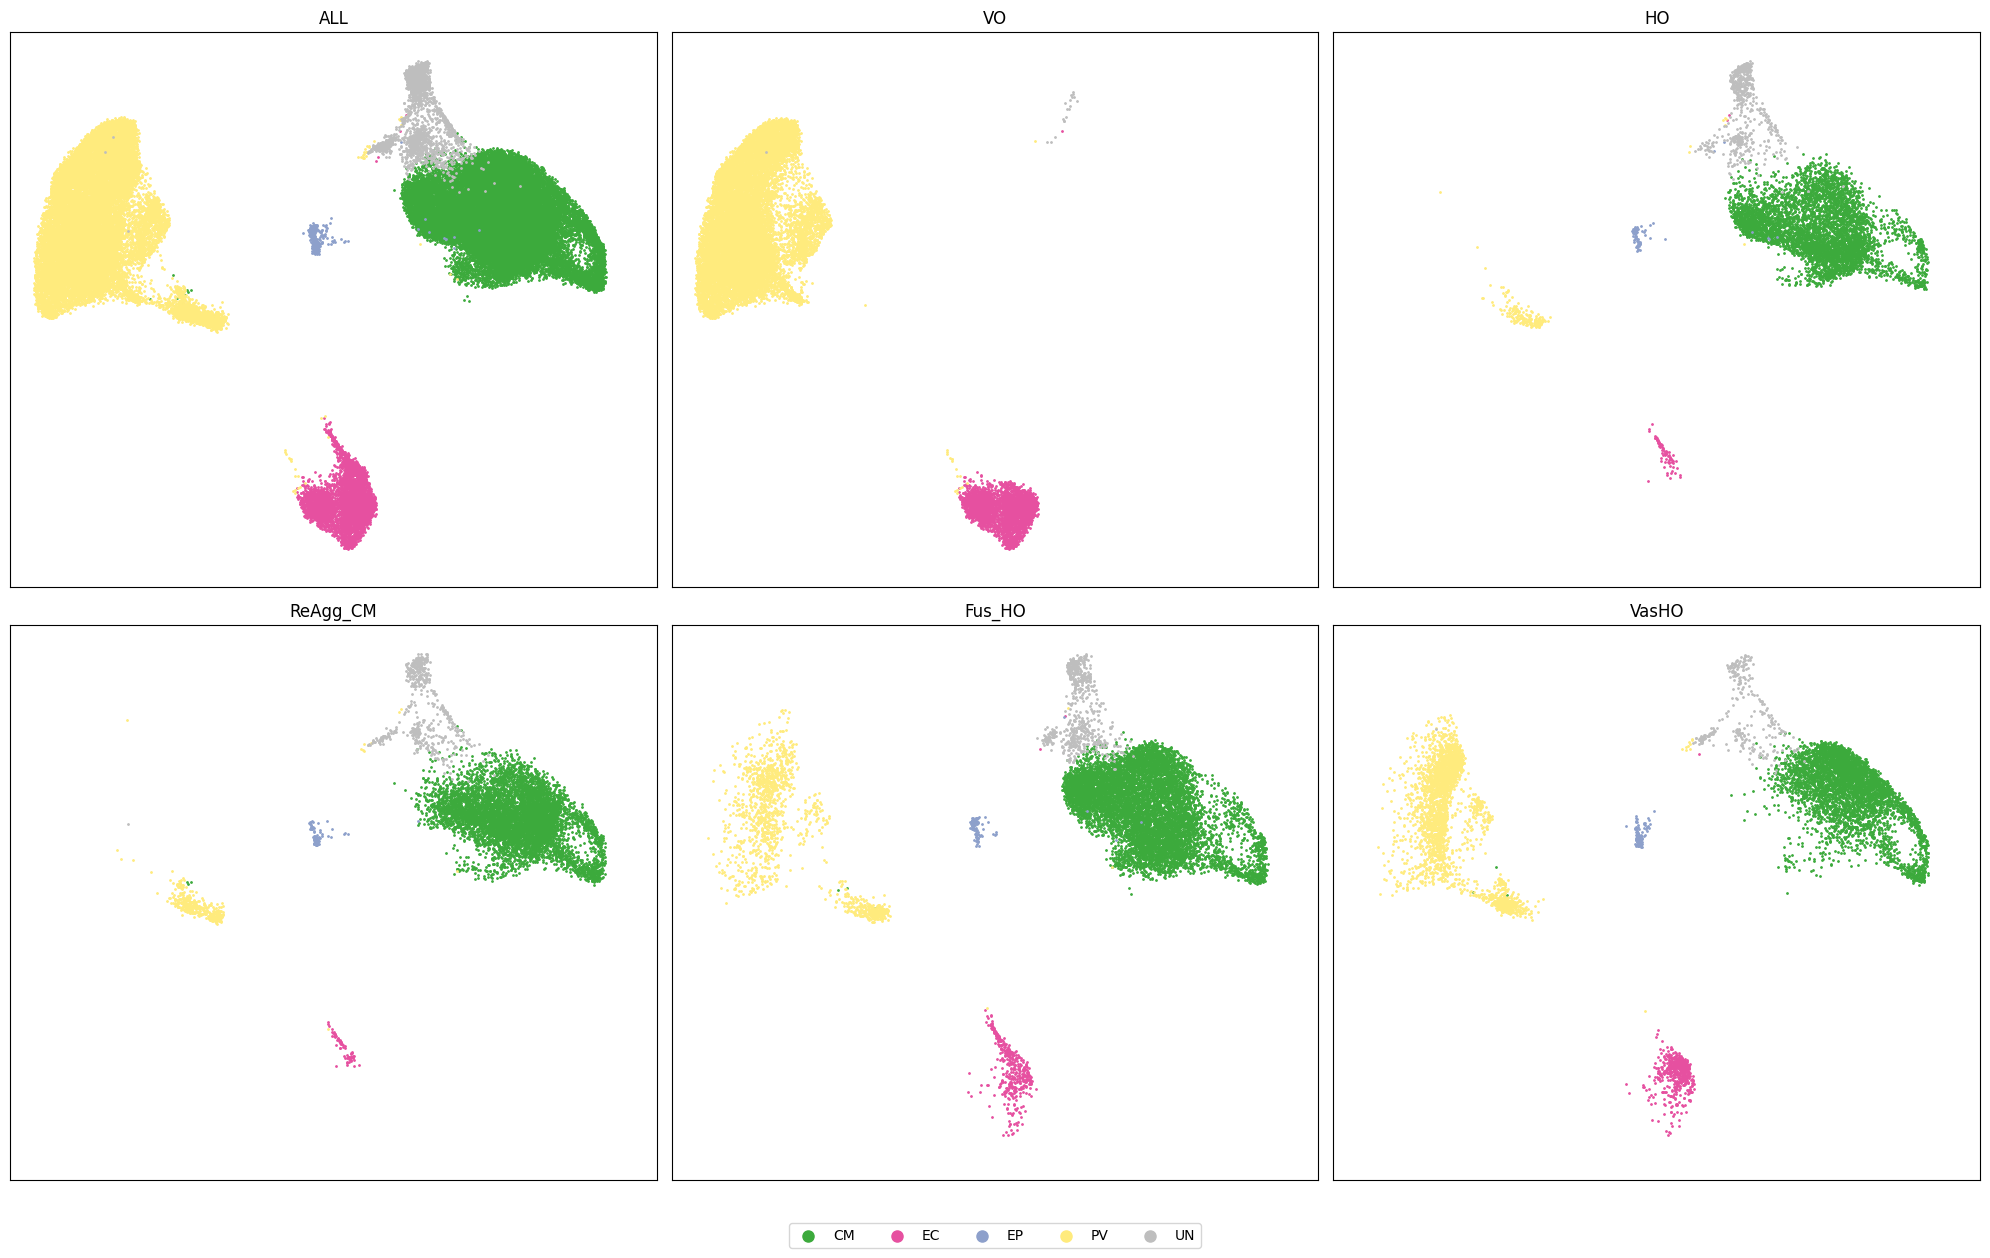

In [43]:
fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):

    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    
    for j, cts in enumerate(adata_all.obs["cell_type"].unique().sort_values()):
        sc_plot = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == cts, 1], 
            label=cts, 
            color=colormap_cpdb[cts], 
            s=1)
                
        if i == 0:
            handles.append(sc_plot)
            labels.append(cts)

    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/cell_type.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/cell_type.complete.svg', bbox_inches="tight")
plt.show()

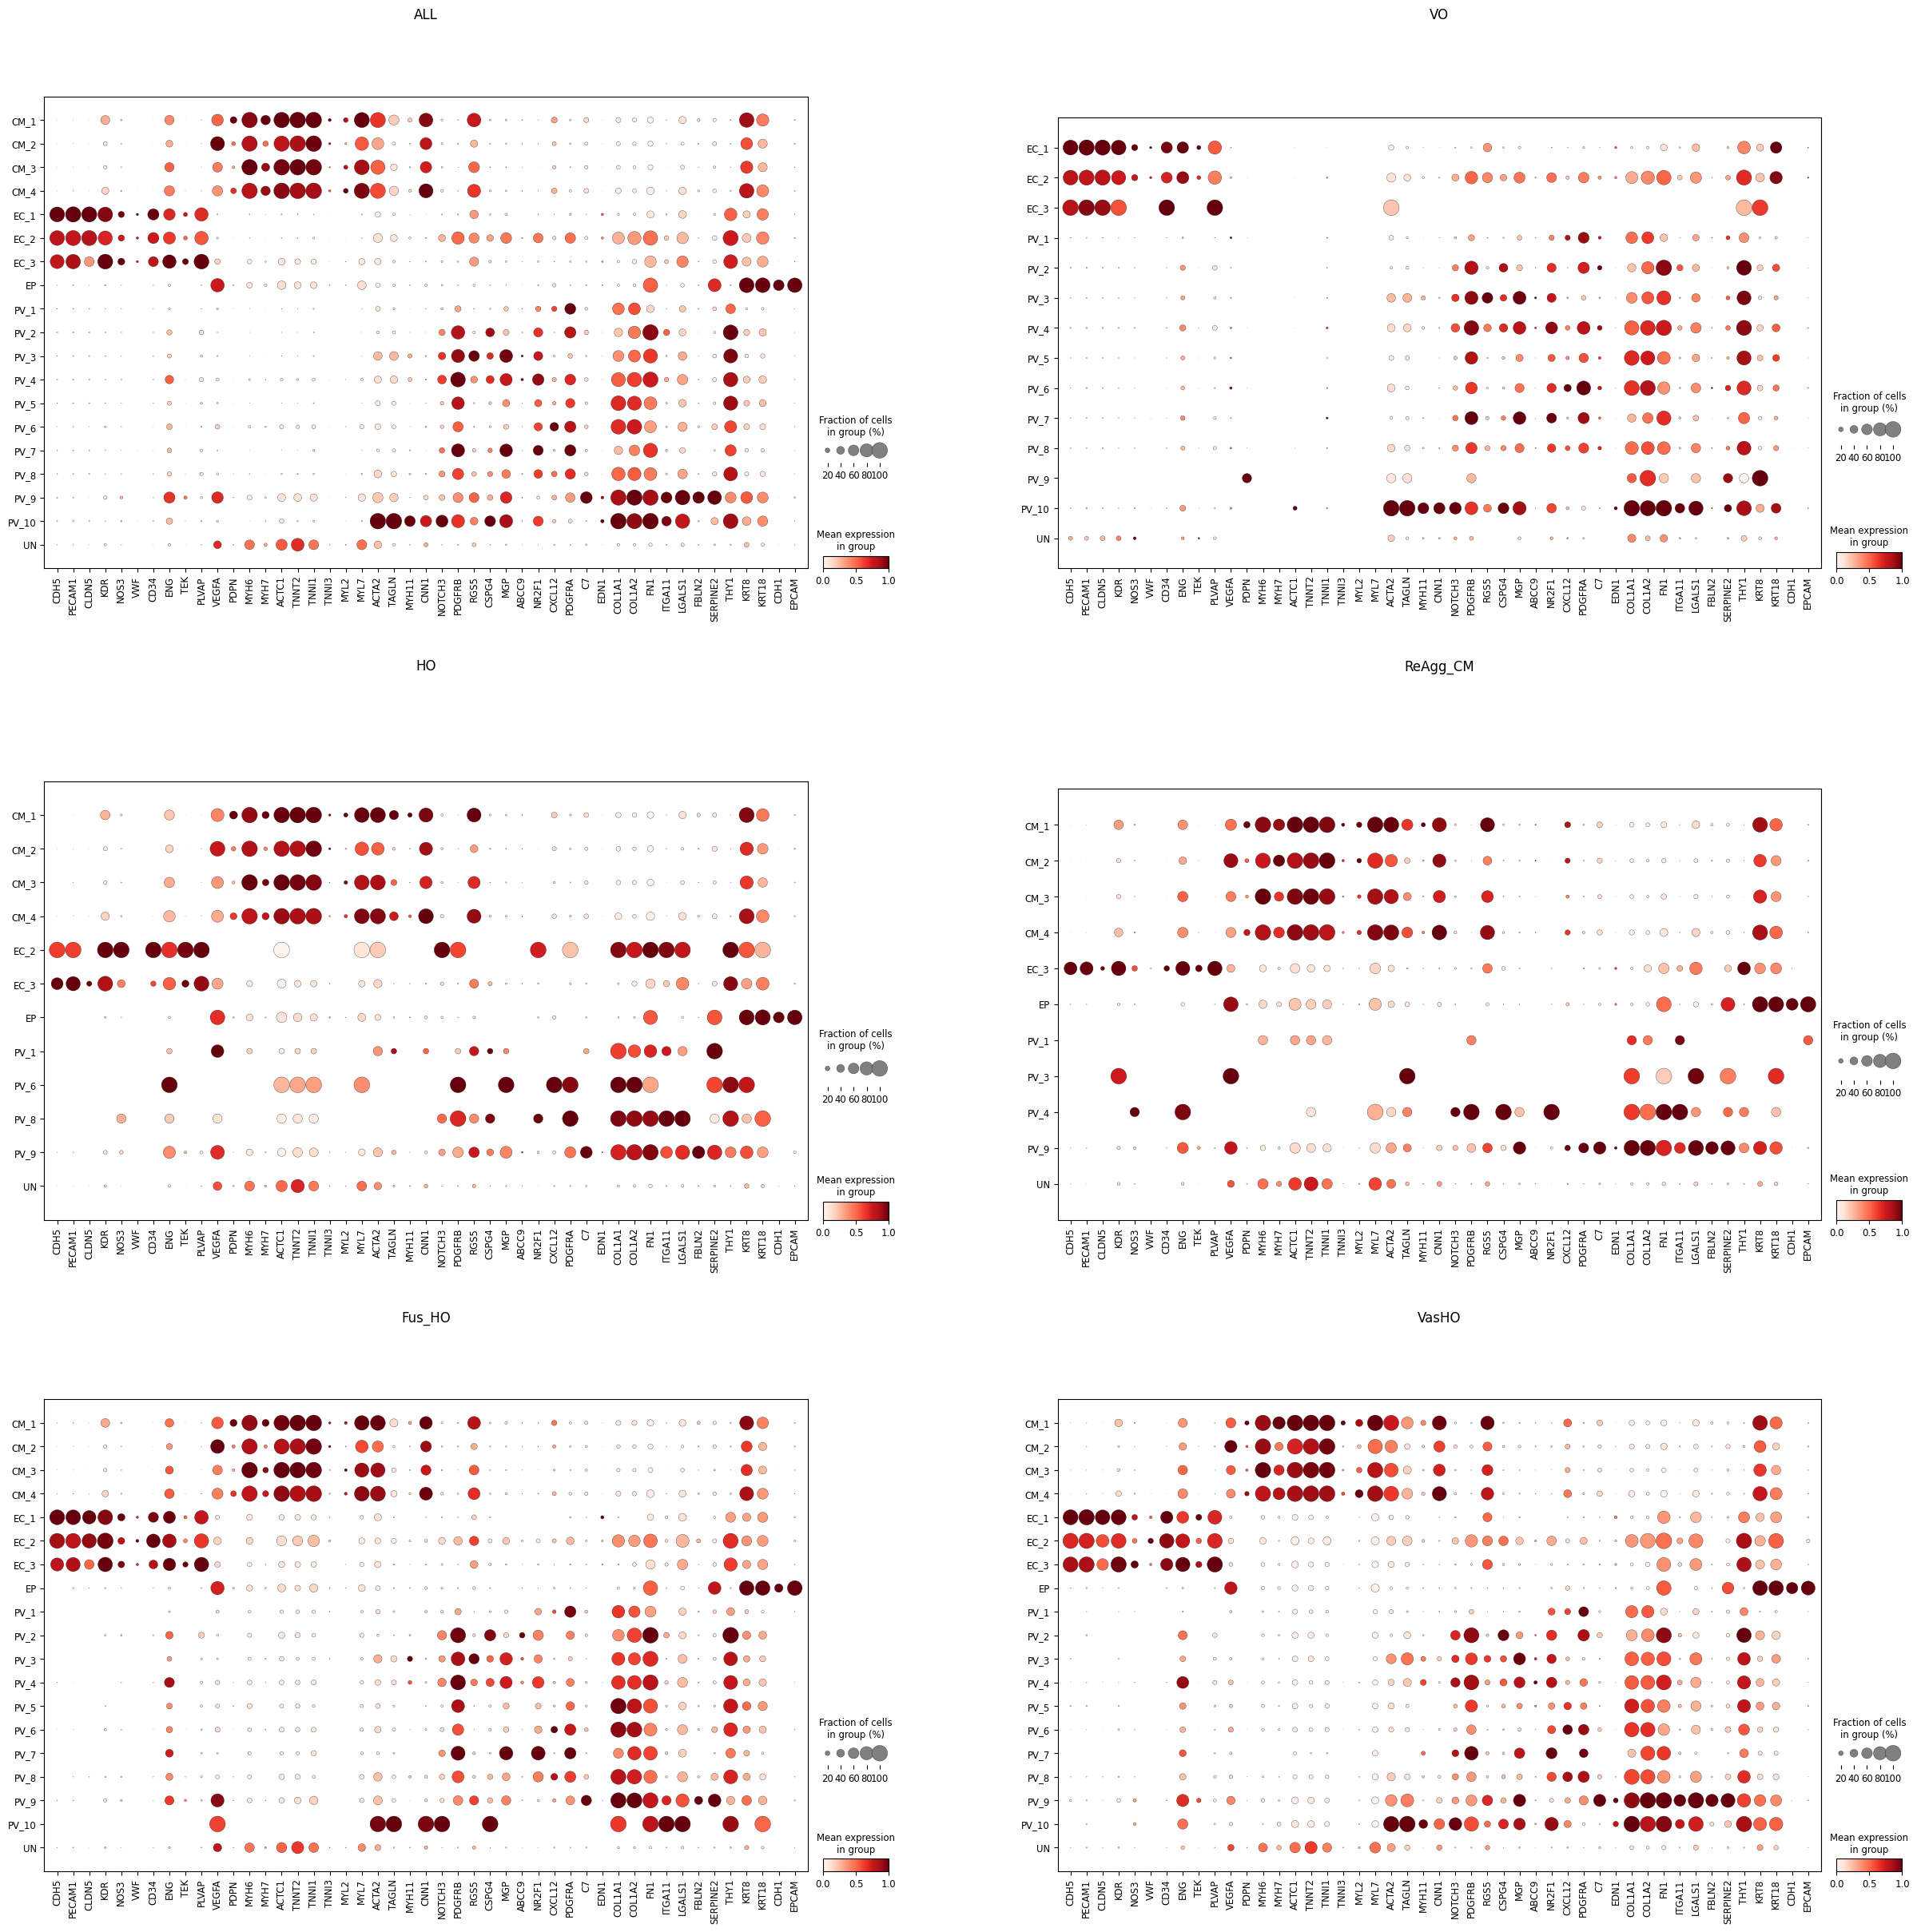

In [46]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

fig, axs = plt.subplots(3, 2, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", ax=axs[i], title=sample, show=False)
    
plt.savefig(f'{WORK_DIR}/dotplot/secondary_label.complete.png')
plt.savefig(f'{WORK_DIR}/dotplot/secondary_label.complete.svg')
plt.show()

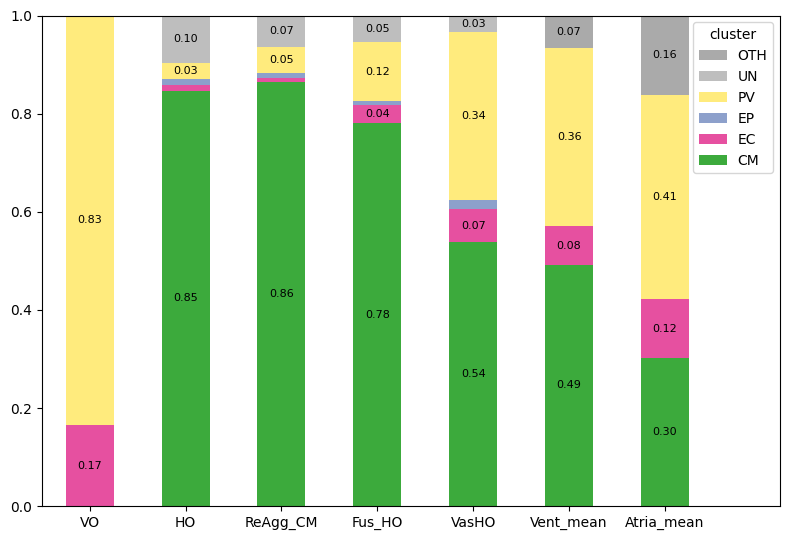

In [52]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cell_type'].value_counts())
    res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df.loc["OTH"] = 0

df["Vent_mean"] = df["VO"].copy()
df["Atria_mean"] = df["Vent_mean"].copy()

df.loc["CM", "Vent_mean"] = 49.2
df.loc["EC", "Vent_mean"] = 7.8
df.loc["EP", "Vent_mean"] = 0
df.loc["PV", "Vent_mean"] = 36.3
df.loc["UN", "Vent_mean"] = 0
df.loc["OTH", "Vent_mean"] = 6.7

df.loc["CM", "Atria_mean"] = 30.1
df.loc["EC", "Atria_mean"] = 12.2
df.loc["EP", "Atria_mean"] = 0
df.loc["PV", "Atria_mean"] = 41.4
df.loc["UN", "Atria_mean"] = 0
df.loc["OTH", "Atria_mean"] = 16.3

df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
df.plot(kind='bar', stacked=True, color=[colormap_cpdb[col] for col in df.columns], ax=ax)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 7.2))
plt.xticks(rotation=0)
# plt.title("Celltype distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/cell_type_wCA.complete_extra.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/cell_type_wCA.complete_extra.svg', bbox_inches="tight")
plt.show()

# 3. DE

# 4. scVelo

# 5. Label transfer

# 6. CellphoneDB